#  _ Preprocessing des données PCOS _

**Étapes :**
1. Chargement et nettoyage
2. Suppression des colonnes inutiles
3. Conversion des colonnes object en numérique
4. Gestion des valeurs manquantes
5. Gestion des outliers (IQR)
6. Sélection des features
7. Séparation X / y
8. Train / Test Split
9. Sauvegarde

---
## Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


---
##  Chargement du dataset

In [2]:
df = pd.read_csv('../data/PCOS_extended_dataset.csv')

df.columns = df.columns.str.strip()

print(f'Shape original : {df.shape}')
print(f'Valeurs cible  : {df["PCOS (Y/N)"].unique()}')
df.head(3)

Shape original : (2000, 44)
Valeurs cible  : [0 1]


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691


---
## Suppression des colonnes inutiles

In [3]:
cols_a_supprimer = ['Sl. No', 'Patient File No.']
cols_a_supprimer = [c for c in cols_a_supprimer if c in df.columns]

df = df.drop(columns=cols_a_supprimer)

print(f'Colonnes supprimées : {cols_a_supprimer}')
print(f'Shape après suppression : {df.shape}')

Colonnes supprimées : ['Sl. No', 'Patient File No.']
Shape après suppression : (2000, 42)


---
##  Conversion des colonnes object en numérique
'PCOS (Y/N)', 'II beta-HCG' et 'AMH' sont stockées en string 

In [4]:
obj_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Colonnes object avant : {obj_cols}')

df[obj_cols] = df[obj_cols].apply(pd.to_numeric, errors='coerce')

print(f'Colonnes object après : {df.select_dtypes(include="object").columns.tolist()}')

Colonnes object avant : ['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']
Colonnes object après : []


---
## Gestion des valeurs manquantes
Seulement 'Marraige Status (Yrs)' a 3 NaN = remplacement par la médiane.

In [5]:
print('Valeurs manquantes avant :')
missing = df.isnull().sum()
print(missing[missing > 0])

imputer = SimpleImputer(strategy='median')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print(f'\nValeurs manquantes après : {df.isnull().sum().sum()}')

Valeurs manquantes avant :
Marraige Status (Yrs)     3
II    beta-HCG(mIU/mL)    5
AMH(ng/mL)                3
dtype: int64

Valeurs manquantes après : 0


---
## Visualisation des outliers AVANT traitement

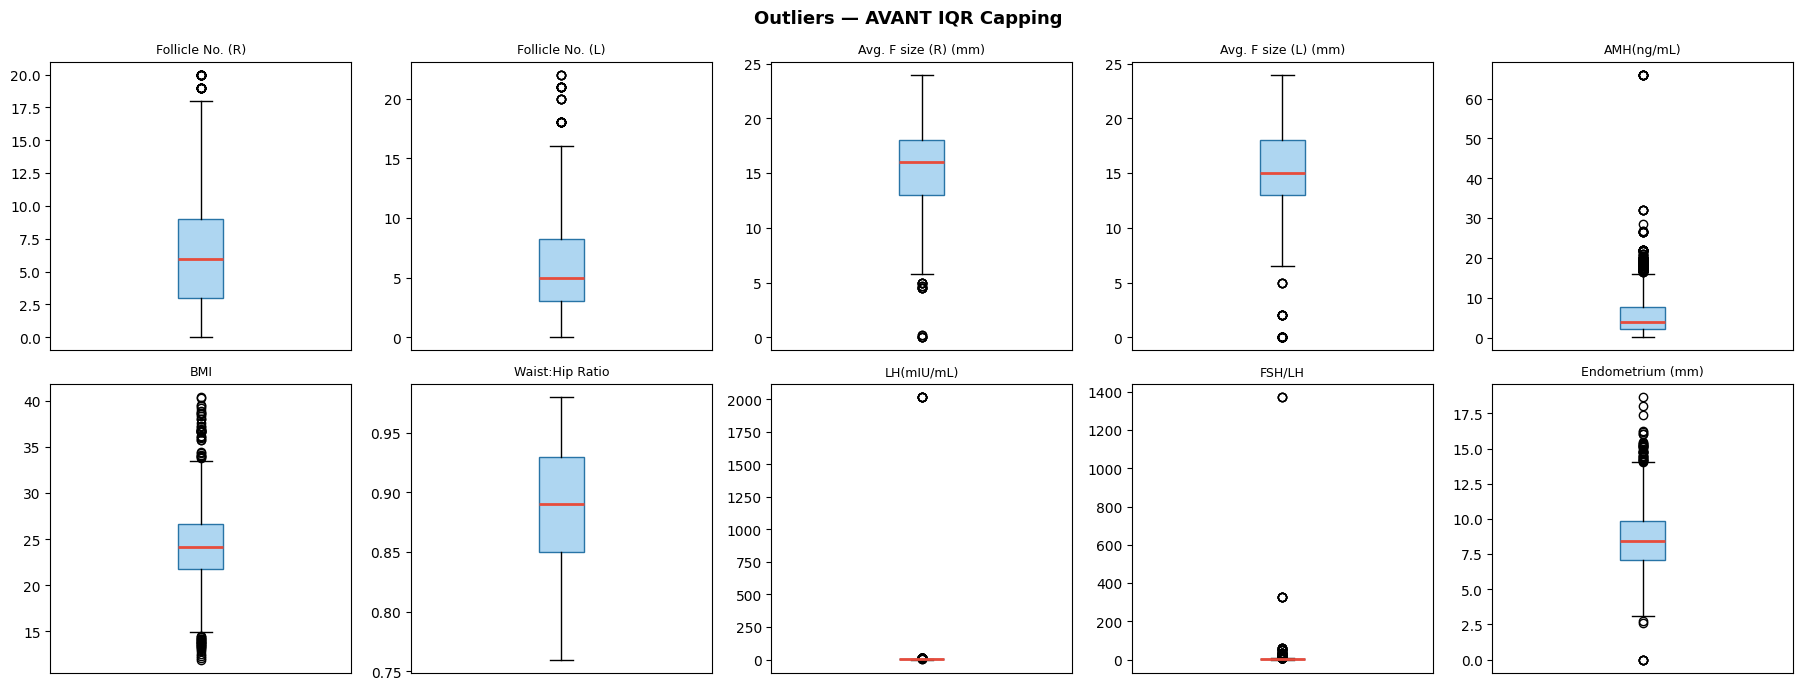

In [6]:
cols_to_cap = [
    'Follicle No. (R)', 'Follicle No. (L)',
    'Avg. F size (R) (mm)', 'Avg. F size (L) (mm)',
    'AMH(ng/mL)', 'BMI', 'Waist:Hip Ratio',
    'LH(mIU/mL)', 'FSH/LH', 'Endometrium (mm)'
]
cols_to_cap = [c for c in cols_to_cap if c in df.columns]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(cols_to_cap):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#2874A6'),
                    medianprops=dict(color='#E74C3C', linewidth=2))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])

plt.suptitle('Outliers — AVANT IQR Capping', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Traitement des outliers (IQR)

- Valeur < Q1 − 1.5×IQR : remplacée par la borne basse
- Valeur > Q3 + 1.5×IQR : remplacée par la borne haute

In [7]:
df_capped = df.copy()

for col in cols_to_cap:
    Q1  = df_capped[col].quantile(0.25)
    Q3  = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df_capped[col] < lower) | (df_capped[col] > upper)).sum()
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

    print(f'{col:35s} → {n_outliers:3d} outliers cappés  '
          f'[{lower:.2f} – {upper:.2f}]')

df = df_capped.copy()

Follicle No. (R)                    →  35 outliers cappés  [-6.00 – 18.00]
Follicle No. (L)                    →  33 outliers cappés  [-4.88 – 16.12]
Avg. F size (R) (mm)                →  19 outliers cappés  [5.50 – 25.50]
Avg. F size (L) (mm)                →  40 outliers cappés  [5.50 – 25.50]
AMH(ng/mL)                          → 159 outliers cappés  [-6.20 – 16.04]
BMI                                 →  61 outliers cappés  [14.51 – 33.85]
Waist:Hip Ratio                     →   0 outliers cappés  [0.73 – 1.05]
LH(mIU/mL)                          →  87 outliers cappés  [-3.19 – 8.04]
FSH/LH                              → 189 outliers cappés  [-2.26 – 7.54]
Endometrium (mm)                    →  42 outliers cappés  [2.93 – 14.04]


---
## Visualisation des outliers APRÈS traitement

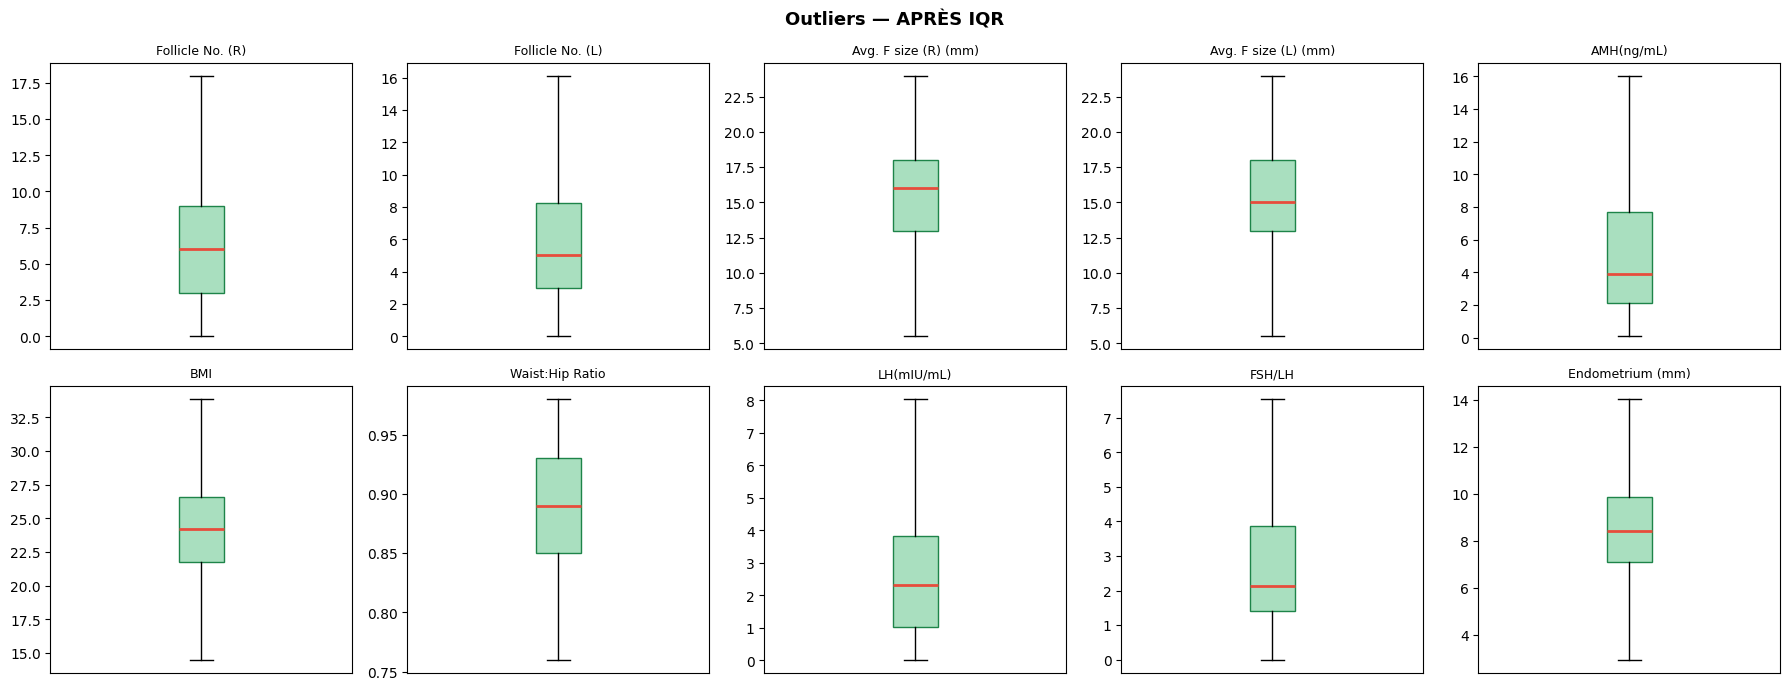

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(cols_to_cap):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#A9DFBF', color='#1E8449'),
                    medianprops=dict(color='#E74C3C', linewidth=2))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xticks([])

plt.suptitle('Outliers — APRÈS IQR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sélection des features
20 features sélectionnées sur la base de la corrélation (EDA) et de la logique médicale.

In [9]:
selected_features = [
    'Follicle No. (R)',
    'Follicle No. (L)',
    'Avg. F size (R) (mm)',
    'Avg. F size (L) (mm)',

    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Pimples(Y/N)',
    'Hair loss(Y/N)',

    'AMH(ng/mL)',
    'Cycle(R/I)',
    'BMI',
    'Waist:Hip Ratio',
    'LH(mIU/mL)',
    'FSH/LH',
    'II    beta-HCG(mIU/mL)',

    'Age (yrs)',
    'Pregnant(Y/N)',
    'Endometrium (mm)',
    'Fast food (Y/N)',
]

selected_features = [f for f in selected_features if f in df.columns]

print(f'Features sélectionnées : {len(selected_features)} / {df.shape[1]-1}')
for i, f in enumerate(selected_features, 1):
    print(f'  {i:2d}. {f}')

Features sélectionnées : 20 / 41
   1. Follicle No. (R)
   2. Follicle No. (L)
   3. Avg. F size (R) (mm)
   4. Avg. F size (L) (mm)
   5. Weight gain(Y/N)
   6. hair growth(Y/N)
   7. Skin darkening (Y/N)
   8. Pimples(Y/N)
   9. Hair loss(Y/N)
  10. AMH(ng/mL)
  11. Cycle(R/I)
  12. BMI
  13. Waist:Hip Ratio
  14. LH(mIU/mL)
  15. FSH/LH
  16. II    beta-HCG(mIU/mL)
  17. Age (yrs)
  18. Pregnant(Y/N)
  19. Endometrium (mm)
  20. Fast food (Y/N)


---
## Séparation X / y

In [10]:
y = df['PCOS (Y/N)'].astype(int)
X = df[selected_features]

print(f'X (features) : {X.shape}')
print(f'y (cible)    : {y.shape}')
print(f'\nDistribution cible :')
print(y.value_counts().rename({0: 'Non-PCOS', 1: 'PCOS'}))

X (features) : (2000, 20)
y (cible)    : (2000,)

Distribution cible :
PCOS (Y/N)
Non-PCOS    1392
PCOS         608
Name: count, dtype: int64


---
## Train / Test Split (80% / 20%)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'\nTaux PCOS — train : {y_train.mean()*100:.1f}%')
print(f'Taux PCOS — test  : {y_test.mean()*100:.1f}%')

X_train : (1600, 20)  |  X_test : (400, 20)

Taux PCOS — train : 30.4%
Taux PCOS — test  : 30.5%


---
## Visualisation du split

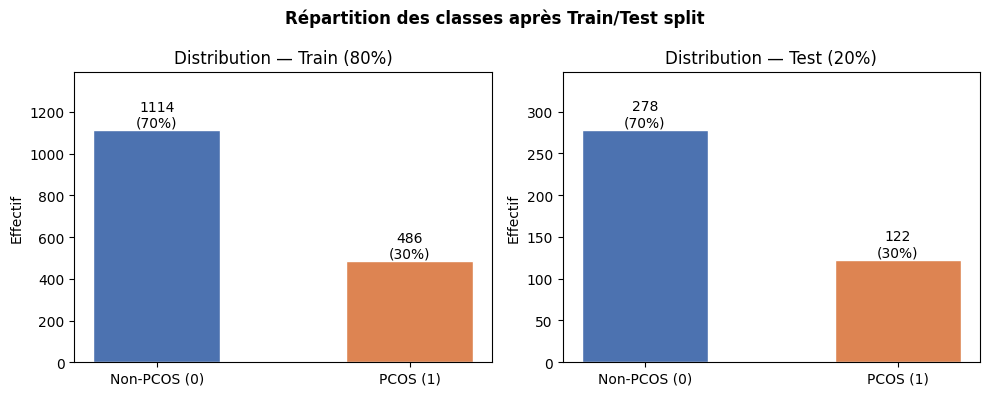

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (nom, y_split) in zip(axes, [('Train (80%)', y_train), ('Test (20%)', y_test)]):
    vals = y_split.value_counts().sort_index()
    bars = ax.bar(['Non-PCOS (0)', 'PCOS (1)'], vals.values,
                  color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{v}\n({v/len(y_split)*100:.0f}%)',
                ha='center', va='bottom', fontsize=10)
    ax.set_title(f'Distribution — {nom}')
    ax.set_ylabel('Effectif')
    ax.set_ylim(0, max(vals.values) * 1.25)

plt.suptitle('Répartition des classes après Train/Test split',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Sauvegarde

In [13]:
import os
os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv',   index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv',   index=False)

print('Sauvegardé dans data/processed/')
print(f'   X_train : {X_train.shape}')
print(f'   X_test  : {X_test.shape}')
print(f'   y_train : {y_train.shape}')
print(f'   y_test  : {y_test.shape}')

Sauvegardé dans data/processed/
   X_train : (1600, 20)
   X_test  : (400, 20)
   y_train : (1600,)
   y_test  : (400,)


---
## Résumé du preprocessing

In [14]:
print('_' * 58)
print('              Résumé — PREPROCESSING')
print('_' * 58)
print(f'  Shape original            : (2000, 44)')
print(f'  Colonnes supprimées       : Sl.No, Patient File No.')
print(f'  Colonnes converties       : PCOS, II beta-HCG, AMH')
print(f'  Valeurs manquantes        : 3 NaN → médiane')
print(f'  Outliers                  : IQR (10 features)')
print(f'  Features sélectionnées    : {len(selected_features)} / 42')
print(f'  Normalisation             : Aucune ici (faite dans le Pipeline du modeling)')
print(f'  Split                     : 80% train / 20% test')
print(f'  X_train                   : {X_train.shape}')
print(f'  X_test                    : {X_test.shape}')
print(f'  Taux PCOS train           : {y_train.mean()*100:.1f}%')
print(f'  Taux PCOS test            : {y_test.mean()*100:.1f}%')
print('_' * 58)

__________________________________________________________
              Résumé — PREPROCESSING
__________________________________________________________
  Shape original            : (2000, 44)
  Colonnes supprimées       : Sl.No, Patient File No.
  Colonnes converties       : PCOS, II beta-HCG, AMH
  Valeurs manquantes        : 3 NaN → médiane
  Outliers                  : IQR (10 features)
  Features sélectionnées    : 20 / 42
  Normalisation             : Aucune ici (faite dans le Pipeline du modeling)
  Split                     : 80% train / 20% test
  X_train                   : (1600, 20)
  X_test                    : (400, 20)
  Taux PCOS train           : 30.4%
  Taux PCOS test            : 30.5%
__________________________________________________________
